<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/04_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 4 · Looking inside models · taste project*

# What is a trained model actually doing inside?

> **In short**
>
> **What is a trained model actually doing inside?**
>
> Its insides are lists of numbers, one list per layer. Many ideas the model uses turn out to be directions in those lists. You can find a direction, measure it, and push along it to change what the model does.

## Where you'll end up

By the end you will have:

1. **Read the numbers inside a trained network** with a PyTorch hook.
2. **Found a direction** in those numbers that means "this digit is round" (left, below).
3. **Pushed a "1" along it** and watched the network's answer change (right, below).
4. **Seen superposition**: a tiny network storing five ideas in two numbers.

This field is applied linear algebra: vectors, dot products, projections, eigenvectors. Running every cell takes about 2 minutes.

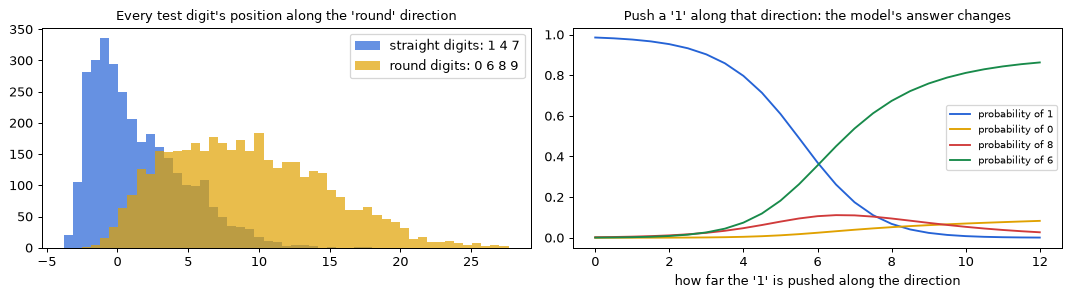

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

## 1. The problem: a network that works, but nobody knows how

Here is a small network that reads handwritten digits. It is 97% accurate.
Inside, it turns every image into **64 numbers**, then turns those into 10 scores.

Nobody told it which features to use. **Does it track an idea like "this digit is round"? Where? How would you check?**
Questions like this, asked about large models, are how researchers check what a model is doing before trusting it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

torch.manual_seed(0)
try:
    tr = torchvision.datasets.MNIST("data", train=True, download=True)
    te = torchvision.datasets.MNIST("data", train=False, download=True)
    X, y = tr.data.float().div(255).flatten(1), tr.targets
    Xt, yt = te.data.float().div(255).flatten(1), te.targets
    SIDE = 28
except Exception as e:
    print("MNIST download failed, using scikit-learn's 8x8 digits:", e)
    from sklearn.datasets import load_digits
    d = load_digits()
    allX, ally = torch.tensor(d.data / 16, dtype=torch.float32), torch.tensor(d.target)
    X, y, Xt, yt = allX[:1400], ally[:1400], allX[1400:], ally[1400:]
    SIDE = 8

model = nn.Sequential(nn.Linear(SIDE * SIDE, 64), nn.ReLU(), nn.Linear(64, 10))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(3):
    order = torch.randperm(len(X))
    for i in range(0, len(X), 128):
        b = order[i:i + 128]
        loss = F.cross_entropy(model(X[b]), y[b])
        opt.zero_grad(); loss.backward(); opt.step()
with torch.no_grad():
    acc = (model(Xt).argmax(1) == yt).float().mean().item()
print(f"test accuracy: {acc:.1%}")

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

 68%|██████▊   | 6.75M/9.91M [00:00<00:00, 66.9MB/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 80.8MB/s]

  0%|          | 0.00/28.9k [00:00<?, ?B/s]

100%|██████████| 28.9k/28.9k [00:00<00:00, 4.36MB/s]

  0%|          | 0.00/1.65M [00:00<?, ?B/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 25.5MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 3.56MB/s]

test accuracy: 95.4%


🐍 **Python notes**
- `nn.Sequential(a, b, c)` chains layers. `model[1]` is the second one (the ReLU).
- `.flatten(1)` turns each 28 × 28 image into one row of 784 numbers.

## 2. Read the numbers inside

A **hook** is a function PyTorch calls every time a layer runs. It receives the layer's output, so you can copy it out.

In [2]:
captured = {}
def save_hidden(module, inputs, output):
    captured["hidden"] = output.detach()

hook = model[1].register_forward_hook(save_hidden)     # model[1] is the ReLU after the first layer
with torch.no_grad():
    model(Xt)
hook.remove()
H = captured["hidden"].numpy()                          # one row of 64 numbers per test digit
labels = yt.numpy()

print("inside numbers:", H.shape, "  (test digits x 64)")
print("digit", labels[0], "looks like this inside:")
print(np.round(H[0], 2))

inside numbers: (10000, 64)   (test digits x 64)
digit 7 looks like this inside:
[1.41 3.05 1.56 2.1  0.58 1.72 0.   0.   2.19 0.97 0.24 2.36 2.71 3.11
 0.   1.92 0.7  1.2  3.03 0.   1.6  4.55 1.1  0.   0.   2.95 0.   2.76
 2.04 2.34 0.   2.13 2.02 0.66 4.15 1.7  0.82 2.14 0.   1.82 0.   0.
 0.73 0.03 2.59 0.25 0.   0.   0.6  0.   1.27 1.12 2.54 0.   0.   4.06
 1.65 0.   4.65 0.43 4.35 1.14 5.37 1.98]


🐍 **Python notes**
- `register_forward_hook(fn)` attaches `fn` to a layer; it returns a handle, and `hook.remove()` detaches it.
- `captured` is a dict defined outside the function; the hook writes into it. (A function can change a dict it can see, without `global`.)

**What it's called:** these 64 numbers are the layer's **activations**. Each test digit is now a point in a 64-dimensional space: a **vector**.

## 3. Is there a "round" neuron?

The simplest guess: one of the 64 numbers means "round". Test each one: how well does it alone sort round digits (0, 6, 8, 9) from straight ones (1, 4, 7)?

In [3]:
ROUND, STRAIGHT = [0, 6, 8, 9], [1, 4, 7]
is_round = np.isin(labels, ROUND)
is_straight = np.isin(labels, STRAIGHT)

direction = H[is_round].mean(0) - H[is_straight].mean(0)    # from the average straight digit to the average round one
direction /= np.linalg.norm(direction)                       # length 1
shadow = H @ direction                                       # every digit's position along the direction

def best_cut(values, positive):
    """Best accuracy from one threshold on these values, either way round."""
    order = np.argsort(values)
    v, p = values[order], positive[order]
    keep = np.isin(labels[order], ROUND + STRAIGHT)
    v, p = v[keep], p[keep]
    pos_below = np.concatenate([[0], np.cumsum(p)])
    neg_below = np.concatenate([[0], np.cumsum(~p)])
    acc = (neg_below + (p.sum() - pos_below)) / len(p)      # cut: below = straight, above = round
    return max(acc.max(), 1 - acc.min())

single = [best_cut(H[:, j], is_round) for j in range(64)]
print(f"best single neuron: number {int(np.argmax(single))}, accuracy {max(single):.1%}")
print(f"the direction:      accuracy {best_cut(shadow, is_round):.1%}")

best single neuron: number 56, accuracy 79.0%
the direction:      accuracy 79.9%


**What you see:** the best single neuron sorts them fairly well, but a **direction**, a weighted mix of all 64 numbers, sorts them better.

How the direction was made: take the average round digit's 64 numbers, subtract the average straight digit's. That arrow points "from straight toward round". Scale it to length 1.
Each digit's position along it is a **dot product**:

$$\cy{\text{shadow}} = \cg{\mathbf{h}} \cdot \cr{\mathbf{d}} = h_1 d_1 + h_2 d_2 + \dots + h_{64} d_{64}$$

**What it's called:** that number is the **projection** of $\mathbf{h}$ onto $\mathbf{d}$: where its shadow falls on the line through $\mathbf{d}$.

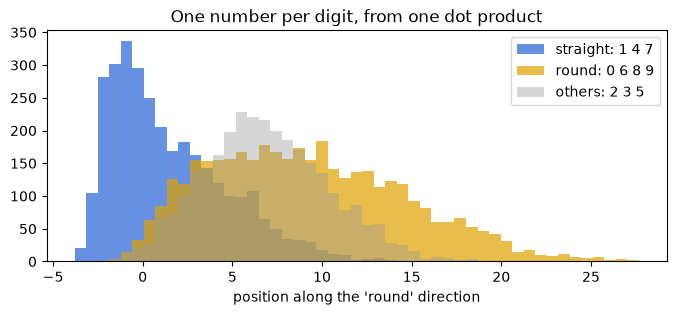

In [4]:
bins = np.linspace(shadow.min(), shadow.max(), 50)
plt.figure(figsize=(8, 3))
plt.hist(shadow[is_straight], bins, color="#2563d6", alpha=0.7, label="straight: 1 4 7")
plt.hist(shadow[is_round], bins, color="#e0a100", alpha=0.7, label="round: 0 6 8 9")
other = ~(is_round | is_straight)
plt.hist(shadow[other], bins, color="#999", alpha=0.4, label="others: 2 3 5")
plt.legend(); plt.xlabel("position along the 'round' direction"); plt.title("One number per digit, from one dot product")
plt.show()

### 🤔 Predict first

The digits 2, 3 and 5 were not used to make the direction. **Where do you expect them to land: with the round digits, with the straight ones, or in between?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**In between, leaning round.** 3 and 5 have curves, 2 has a curve and a straight base. The direction measures curviness, not only membership of the two groups. Look at the grey bars.

</details>

## 4. Looking at 64 dimensions on a flat page

You can't plot 64 numbers. Find the two directions along which the points spread out the most, and draw each point's shadow on those two.

Those directions are the top **eigenvectors** of the activations' **covariance matrix** (a 64 × 64 table of how each pair of numbers varies together). Your linear algebra course covers eigenvectors; here is one use.

share of the spread these two directions capture: 43.0%


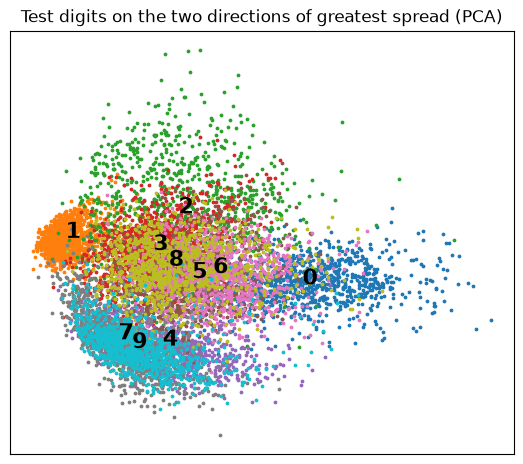

In [5]:
Hc = H - H.mean(0)                          # move the centre of the cloud to the origin
cov = Hc.T @ Hc / len(Hc)                   # 64 x 64 covariance matrix
vals, vecs = np.linalg.eigh(cov)            # eigenvalues in increasing order
top2 = vecs[:, -2:][:, ::-1]                # the two with the biggest eigenvalues
xy = Hc @ top2
print(f"share of the spread these two directions capture: {vals[-2:].sum() / vals.sum():.1%}")

plt.figure(figsize=(6.5, 5.5))
for d in range(10):
    m = labels == d
    plt.scatter(xy[m, 0], xy[m, 1], s=3, label=str(d))
    plt.text(*np.median(xy[m], 0), str(d), fontsize=16, weight="bold")
plt.title("Test digits on the two directions of greatest spread (PCA)"); plt.xticks([]); plt.yticks([])
plt.show()

🐍 `np.linalg.eigh` finds eigenvalues and eigenvectors of a symmetric matrix. `vecs[:, -2:][:, ::-1]` takes the last two columns, biggest first.

**What it's called:** this is **PCA** (principal component analysis). An **eigenvector** of the covariance matrix is a direction the matrix only stretches; its **eigenvalue** says by how much, which here equals the spread of the data along it.

## 5. Push along the direction

If the direction really means "round" **to the model**, then moving a digit's 64 numbers along it should change the model's answer toward round digits.

Take a "1". Compute its 64 numbers. Add $\alpha \times$ the direction, for growing $\alpha$. Feed the result to the last layer.

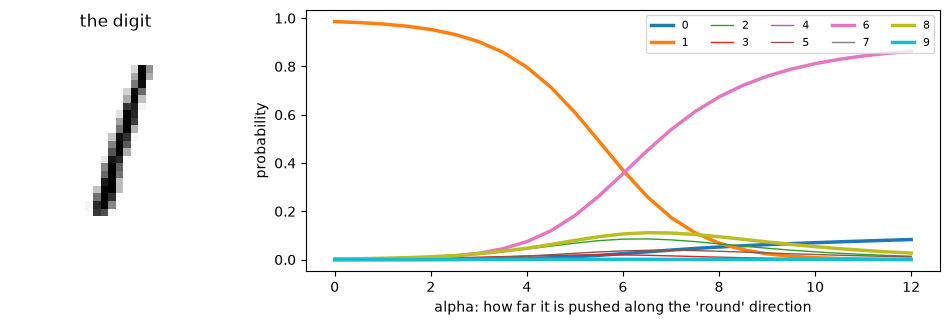

at alpha = 0 the model says 1 (99%); at alpha = 12 it says 6 (86%)


In [6]:
d = torch.tensor(direction, dtype=torch.float32)
k = int(np.flatnonzero(labels == 1)[0])
alphas = np.linspace(0, 12, 25)

def push(direction_vec, alphas, k):
    out = []
    with torch.no_grad():
        h = F.relu(model[0](Xt[k:k + 1]))
        for a in alphas:
            out.append(F.softmax(model[2](h + a * direction_vec), dim=1)[0].numpy())
    return np.array(out)

probs = push(d, alphas, k)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1, 3]})
axes[0].imshow(Xt[k].reshape(SIDE, SIDE), cmap="gray_r"); axes[0].set_title("the digit"); axes[0].axis("off")
for digit in range(10):
    axes[1].plot(alphas, probs[:, digit], label=str(digit), lw=2.5 if digit in (1, 0, 6, 8, 9) else 1)
axes[1].set_xlabel("alpha: how far it is pushed along the 'round' direction"); axes[1].set_ylabel("probability")
axes[1].legend(ncol=5, fontsize=8); plt.show()
top = probs[-1].argmax()
print(f"at alpha = 0 the model says 1 ({probs[0, 1]:.0%}); at alpha = 12 it says {top} ({probs[-1, top]:.0%})")

**What it's called:** changing a model's behaviour by adding a direction to its activations is **steering**.

### Careful measurement: is it the direction, or any push?

A fair test needs a **control**. Push the same "1" by the same amount along **random** directions of length 1. If those also change the answer, the result above means little.

In [7]:
rng = np.random.default_rng(0)
changed = 0
for trial in range(20):
    r = rng.normal(size=64); r /= np.linalg.norm(r)
    p = push(torch.tensor(r, dtype=torch.float32), [12.0], k)[0]
    changed += int(p.argmax() != 1)
print(f"random directions that changed the answer away from 1: {changed} of 20")

random directions that changed the answer away from 1: 2 of 20


**What you see:** most random pushes of the same size leave the answer at 1. The "round" direction is special.
Checking against a control like this is basic **experiment design**, and the core skill of the field.

### The library version: a probe

A **probe** is a small model trained to read an idea out of activations. Logistic regression (from scikit-learn) finds a direction too, chosen to separate the two groups as well as possible. Compare it with your averaged-difference direction.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

keep = is_round | is_straight
Htr, Hte, ytr, yte = train_test_split(H[keep], is_round[keep], test_size=0.3, random_state=0)
probe = LogisticRegression(max_iter=2000).fit(Htr, ytr)
w = probe.coef_[0] / np.linalg.norm(probe.coef_[0])
print(f"probe accuracy on held-out digits: {probe.score(Hte, yte):.1%}")
print(f"angle between probe direction and your direction: {np.degrees(np.arccos(np.clip(w @ direction, -1, 1))):.0f} degrees")

probe accuracy on held-out digits: 96.5%
angle between probe direction and your direction: 76 degrees


**What you see:** the probe scores higher on held-out digits, and its direction points roughly the same way as yours. The cosine of the angle between two length-1 vectors is their dot product.
(The probe was tested on digits it didn't train on: a train/test split, again.)

## 6. More ideas than numbers: superposition

The digit network has 64 numbers but may track more than 64 ideas. How can that work?

A small experiment: five features, each usually 0 and occasionally on. Squeeze them through **two** numbers and back out, and train the squeeze to keep as much as possible.

### 🤔 Predict first

Two numbers can hold two independent directions at right angles. **With five rarely-on features, how many will the trained squeeze keep?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**All five**, as five directions spread around a circle (like a pentagon). They overlap, but because features are rarely on at the same time, the overlap rarely causes errors. Run the next cell.

</details>

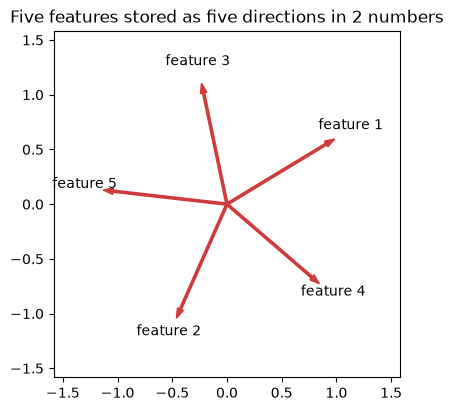

lengths of the five feature arrows: [1.15 1.14 1.13 1.11 1.14]


In [9]:
torch.manual_seed(1)
N_FEAT, N_DIM, P_ON = 5, 2, 0.05
Wsq = nn.Parameter(torch.randn(N_DIM, N_FEAT) * 0.5)
bias = nn.Parameter(torch.zeros(N_FEAT))
opt = torch.optim.Adam([Wsq, bias], lr=0.02)
for step in range(4000):
    x = torch.rand(1024, N_FEAT) * (torch.rand(1024, N_FEAT) < P_ON)    # sparse: each feature on 5% of the time
    out = F.relu(x @ Wsq.T @ Wsq + bias)                                  # squeeze to 2 numbers, expand back to 5
    loss = ((out - x) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

cols = Wsq.detach().numpy()
plt.figure(figsize=(4.5, 4.5))
for j in range(N_FEAT):
    plt.arrow(0, 0, cols[0, j], cols[1, j], width=0.02, color="#d03a3a", length_includes_head=True)
    plt.text(cols[0, j] * 1.15, cols[1, j] * 1.15, f"feature {j + 1}", ha="center")
lim = np.abs(cols).max() * 1.4
plt.xlim(-lim, lim); plt.ylim(-lim, lim); plt.gca().set_aspect("equal")
plt.title("Five features stored as five directions in 2 numbers"); plt.show()
print("lengths of the five feature arrows:", np.round(np.linalg.norm(cols, axis=0), 2))

**What you see:** the five arrows spread around the circle, each with a similar length: all five features survive in two numbers.

**What it's called:** storing more features than dimensions, as overlapping directions, is **superposition**. It is why single neurons in big models often respond to several unrelated things, and why researchers look for directions instead of neurons.

## Practice

Try each one before opening its solution.

### Exercise 1

By hand: $\mathbf{h} = (3, 1)$ and $\mathbf{d} = (0.6, 0.8)$ (length 1). **Where does $\mathbf{h}$'s shadow fall along $\mathbf{d}$? Which lands further along: (1, 2) or (2, 1)?**

<details><summary><b>Show the answer to exercise 1</b></summary>

$3 \times 0.6 + 1 \times 0.8 = 2.6$. For (1, 2): $0.6 + 1.6 = 2.2$. For (2, 1): $1.2 + 0.8 = 2.0$. So (1, 2) lands further along.

</details>

### Exercise 2

Find a direction for **thick versus thin** strokes. (Hint: count each test image's ink, `Xt.sum(1)`, and compare the thickest third with the thinnest third.) **How well does it sort them, and is it the same as the round direction?**

In [10]:
# your code here

In [11]:
#@title Solution to exercise 2 (double-click to show)
ink = Xt.sum(1).numpy()
thick, thin = ink > np.percentile(ink, 67), ink < np.percentile(ink, 33)
thick_dir = H[thick].mean(0) - H[thin].mean(0)
thick_dir /= np.linalg.norm(thick_dir)
s = H @ thick_dir
both = thick | thin
acc = ((s[both] > np.median(s[both])) == thick[both]).mean()
print(f"thick-vs-thin accuracy with a median cut: {acc:.1%}")
print(f"angle to the round direction: {np.degrees(np.arccos(abs(thick_dir @ direction))):.0f} degrees")
# A separate direction, at a large angle to 'round': the 64 numbers hold several ideas at once.

thick-vs-thin accuracy with a median cut: 93.2%
angle to the round direction: 29 degrees


### Exercise 3

Steer the other way: start from a **0** and push along **minus** the round direction. **What does the model say as you push further?**

In [12]:
# your code here

In [13]:
#@title Solution to exercise 3 (double-click to show)
k0 = int(np.flatnonzero(labels == 0)[0])
p = push(-d, alphas, k0)
for a, row in zip(alphas[::4], p[::4]):
    print(f"alpha {a:5.1f}: says {row.argmax()} ({row.max():.0%})")

alpha   0.0: says 0 (100%)
alpha   2.0: says 0 (100%)
alpha   4.0: says 0 (99%)
alpha   6.0: says 0 (89%)
alpha   8.0: says 7 (65%)
alpha  10.0: says 7 (96%)
alpha  12.0: says 7 (100%)


## Recognition cues

- When you see **"does the model represent X?"** in a problem, think **train a probe on activations, and test it on held-out examples**.
- When you see **"how much does this vector point along that one?"** in a problem, think **a dot product (projection onto a length-1 vector)**.
- When you see **"too many dimensions to look at"** in a problem, think **PCA: the top eigenvectors of the covariance matrix**.
- When you see **an effect from an intervention** in a problem, think **compare against a control (for example, random directions)**.

## Try changing this

1. **A deeper network.** Add a second hidden layer and find the round direction in each layer. In which layer does it sort best?
2. **Fewer neurons.** Train with 16 hidden numbers instead of 64. Does the round direction still exist?
3. **More features.** In the superposition experiment, try 8 features and `P_ON = 0.3`. What happens to the arrows when features are often on together?

## Open research questions

People are working on these right now:

- Can we read a model's "thoughts" reliably?
- Can we check a model is safe by looking inside it?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Looking inside models** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- ARENA interpretability curriculum (free exercises): https://github.com/callummcdougall/ARENA_3.0
- transformer-circuits.pub (research articles on what is inside transformers): https://transformer-circuits.pub/
- TransformerLens library (hooks for language models): https://github.com/TransformerLensOrg/TransformerLens
- At Monash: builds on FIT5215 Deep learning; a strong candidate for research.